# Session 14 — Outlier Identification and Basic Treatment Methods
### Module 4: Data Cleaning, Visualization and EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 1. Loading the Dataset


In [2]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.shape

(53940, 10)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


**About the dataset:** each row is a diamond with attributes like `carat` (weight), `price`, `depth`, `table`, and physical dimensions `x`, `y`, `z`. Real-world measurement and pricing data like this almost always contains outliers — extremely large/small stones, data entry errors (e.g. a dimension of 0), and unusually priced items.


## 2. What Is an Outlier?

An outlier is a data point that differs significantly from the rest of the data. Outliers can arise from:
- **Genuine rare events** (e.g. an exceptionally large, high-value diamond)
- **Data entry / measurement errors** (e.g. a dimension recorded as 0 or a negative price)
- **Natural variability** in the underlying process

The correct treatment depends on *which* of these is the cause — this is why outlier handling always requires judgment, not just a formula.


## 3. Visual Identification of Outliers

### 3.1 Boxplot

The boxplot is the most common way to visually spot outliers. Points beyond the "whiskers" (typically 1.5 × IQR from the quartiles) are flagged as potential outliers.


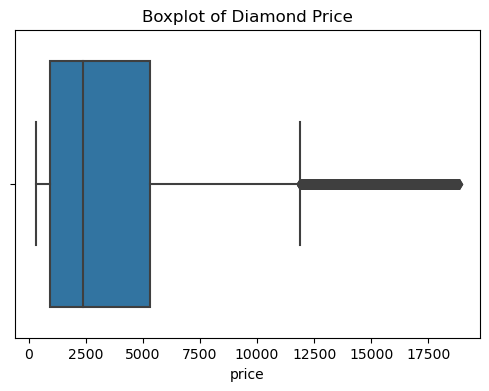

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Diamond Price')
plt.show()

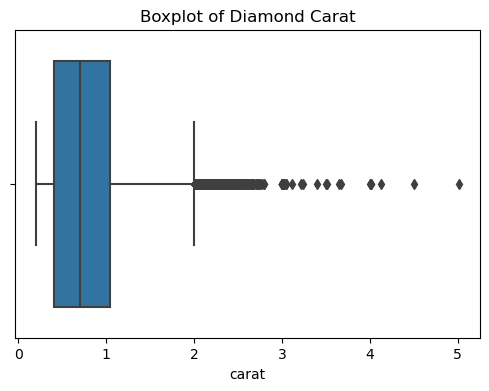

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['carat'])
plt.title('Boxplot of Diamond Carat')
plt.show()


## 4. Statistical Identification of Outliers

### 4.1 The IQR (Interquartile Range) Method

The most common rule of thumb:
- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 - Q1
- A value is an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`


In [11]:
def find_outliers_iqr(series):
    """Return a boolean mask marking outliers in a numeric Series using the IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)


In [12]:
price_outliers = find_outliers_iqr(df['price'])
print("Number of price outliers (IQR method):", price_outliers.sum())
df[price_outliers].head()


Number of price outliers (IQR method): 3540


,carat,cut,color,clarity,depth,table,price,x,y,z
23820,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68


In [13]:
carat_outliers = find_outliers_iqr(df['carat'])
print("Number of carat outliers (IQR method):", carat_outliers.sum())


Number of carat outliers (IQR method): 1889


### 4.2 The Z-Score Method

The Z-score measures how many standard deviations a value is from the mean. A common threshold is `|z| > 3`.

**Note:** Z-score assumes roughly normal (bell-shaped) data. It is less reliable on strongly skewed columns like `price` here, but useful to know and compare against the IQR method.


In [14]:
def find_outliers_zscore(series, threshold=3):
    """Return a boolean mask marking outliers in a numeric Series using the Z-score method."""
    mean = series.mean()
    std = series.std()
    z_scores = (series - mean) / std
    return z_scores.abs() > threshold


In [15]:
depth_outliers = find_outliers_zscore(df['depth'])
print("Number of depth outliers (Z-score method):", depth_outliers.sum())


Number of depth outliers (Z-score method): 685


In [16]:
table_outliers = find_outliers_zscore(df['table'])
print("Number of table outliers (Z-score method):", table_outliers.sum())


Number of table outliers (Z-score method): 336


## 5. Column-by-Column Outlier Strategy

Each numeric column is assessed individually with the reasoning written as a comment — the correct treatment is not the same for every column.


In [17]:
# ---- x, y, z (physical dimensions in mm) ----
# A value of 0 is physically impossible for a diamond's dimensions -- this is a
# data entry error, not a genuine outlier or rare event.
# Strategy: treat 0 values as invalid and drop those rows, since they cannot be
# reasonably imputed without risking incorrect data.
invalid_dimensions = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
print("Rows with invalid (zero) dimensions:", invalid_dimensions.sum())
df = df[~invalid_dimensions]


Rows with invalid (zero) dimensions: 20


In [18]:
# ---- carat ----
# Numeric column, right-skewed (most diamonds are small, a few are very large).
# Large carat values are likely genuine rare/expensive diamonds, not errors.
# Strategy: do NOT remove these outliers outright -- capping (winsorizing) is safer
# than deletion, since large diamonds are valid, valuable data points.
Q1 = df['carat'].quantile(0.25)
Q3 = df['carat'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
df['carat_capped'] = df['carat'].clip(upper=upper_cap)
print("Original max carat:", df['carat'].max(), " | Capped max carat:", df['carat_capped'].max())


Original max carat: 5.01  | Capped max carat: 2.0


In [19]:
# ---- price ----
# Numeric column, strongly right-skewed (a small number of very expensive diamonds).
# These are genuine, meaningful values -- removing them would distort the very
# thing we want to study (pricing behaviour of premium diamonds).
# Strategy: apply a log transformation instead of removing/capping, which reduces
# the influence of extreme values while keeping all data points.
df['log_price'] = np.log1p(df['price'])


In [21]:
# ---- depth, table (percentage-style measurements) ----
# Numeric columns, roughly bell-shaped, with a small number of extreme values likely
# caused by measurement/rounding error rather than genuine rare diamonds.
# Strategy: cap extreme values using the IQR bounds, keeping the row but reducing
# the distortion caused by extreme values.
for col in ['depth', 'table']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

df[['depth', 'table']].describe()


,depth,table
count,53920.000000,53920.000000
mean,61.749229,57.438270
std,1.269961,2.160902
min,58.750000,51.500000
25%,61.000000,56.000000
50%,61.800000,57.000000
75%,62.500000,59.000000
max,64.750000,63.500000


## 6. General Treatment Methods — Summary

| Method | What it does | When to use |
|---|---|---|
| **Trimming (removal)** | Delete rows identified as outliers | When outliers are clearly data errors (e.g. impossible values) |
| **Capping / Winsorizing** | Replace extreme values with a boundary value (e.g. Q3 + 1.5×IQR) | When extreme values are plausible but should not dominate analysis |
| **Transformation** | Apply log, square-root, etc. to reduce skew | When the whole column is skewed by naturally large values (e.g. price, income) |
| **Imputation** | Replace outliers with mean/median, similar to missing values | When outliers are likely errors but the row should be kept |
| **Keep as-is + flag** | Leave outliers untouched, add an indicator column | When outliers are the actual phenomenon of interest (e.g. fraud detection) |


In [22]:
# Example: trimming vs capping side-by-side, using price
price_trimmed = df[~find_outliers_iqr(df['price'])]['price']
price_capped = df['price'].clip(
    upper=df['price'].quantile(0.75) + 1.5 * (df['price'].quantile(0.75) - df['price'].quantile(0.25))
)

print("Original rows:", len(df))
print("Rows after trimming price outliers:", len(price_trimmed))
print("Rows after capping (unchanged):", len(price_capped))


Original rows: 53920
Rows after trimming price outliers: 50388
Rows after capping (unchanged): 53920


## 7. Visual Before/After Comparison


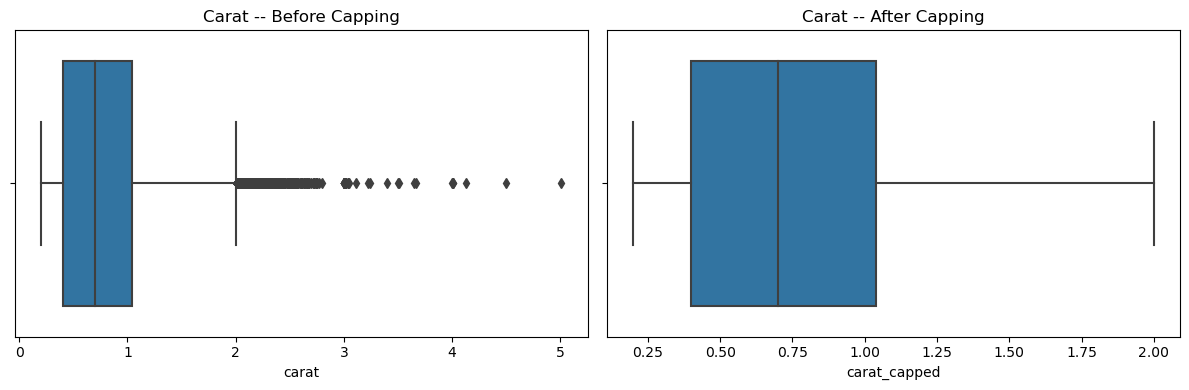

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['carat'], ax=axes[0])
axes[0].set_title('Carat -- Before Capping')

sns.boxplot(x=df['carat_capped'], ax=axes[1])
axes[1].set_title('Carat -- After Capping')

plt.tight_layout()
plt.show()


## 8. Hands-on Practice Exercise 1 — Detection

Using the `diamonds` dataset (reload with `sns.load_dataset('diamonds')` for a fresh copy if needed):

1. Use the IQR method to count outliers in the `table` column
2. Use the Z-score method to count outliers in the `carat` column
3. Compare the two counts -- do IQR and Z-score agree? Why might they differ on a skewed column?
4. Create a boxplot for the `depth` column and visually confirm the outlier count matches your statistical calculation


In [24]:
# Write your solution here



## 9. Hands-on Practice Exercise 2 — Treatment

1. Identify and remove any rows with a dimension (`x`, `y`, or `z`) equal to 0, with a comment explaining why removal (not imputation) is appropriate here
2. Apply capping to the `table` column using the IQR bounds
3. Apply a log transformation to `carat` and compare its histogram before and after
4. In a markdown cell, write 2-3 sentences justifying which treatment method you would use for `price` and why


In [25]:
# Write your solution here



## 10. Hands-on Practice Exercise 3 — End-to-End

1. Reload a fresh copy of the `diamonds` dataset
2. For every numeric column, decide and apply a treatment strategy (trim / cap / transform / keep) with a comment explaining your reasoning, similar to Section 5
3. Generate a boxplot for each treated column to visually confirm the effect
4. Save the cleaned dataset to a new CSV file


In [26]:
# Write your solution here



## Key Terms Glossary

| Term | Meaning |
|---|---|
| Outlier | A data point significantly different from the rest of the data |
| IQR (Interquartile Range) | Q3 - Q1; used to define outlier boundaries |
| Z-score | Number of standard deviations a value is from the mean |
| Trimming | Removing outlier rows entirely |
| Capping / Winsorizing | Replacing extreme values with a boundary value |
| `clip()` | Pandas method to cap values at a lower/upper bound |
| Log transformation | Applying `log()` to reduce the effect of large values / skew |
| Skewness | Asymmetry in a distribution (e.g. a long right tail) |


## Common Mistakes to Avoid

- Automatically deleting every statistical outlier without checking if it's a genuine, valid data point
- Using the Z-score method on strongly skewed data, where it can be misleading
- Applying the same outlier threshold/method to every column without considering what the column represents
- Capping or removing outliers *before* checking whether they are actually data entry errors (like a dimension of 0)
- Forgetting to visually confirm statistical outlier detection with a boxplot or histogram
- Removing too many rows through aggressive trimming, especially on naturally skewed real-world columns like `price`


## Homework / Practice Assignment

1. Pick any numeric dataset (can be `sns.load_dataset('tips')`, `sns.load_dataset('penguins')`, or your own CSV file)
2. For at least 3 numeric columns, detect outliers using both the IQR method and the Z-score method
3. For each column, decide on and apply an appropriate treatment (trim / cap / transform / keep), with a comment explaining your reasoning
4. Create before/after boxplots for each treated column
5. Come prepared with 2 questions/doubts for the next session on matplotlib visualizations
